# Receipt NER model test - real photos

Runs the trained model (`ai/saved_pytorch_model/`, from
`receipt_ner_gpu_training.ipynb`) against 5 real receipt photos in
`ai/ocrtest/`, pulls out COMPANY/DATE/ADDRESS/TOTAL, and shows the results
as a table plus a bounding-box picture for each receipt.

## Two things worth knowing before trusting these results

This tests the model on its own, not the whole app. In the real app, OCR
is done by Google ML Kit on-device in Flutter, with a document scanner
running first to find the receipt's edges, crop it, straighten it, and
boost the contrast. None of that is available here in Python, so this
notebook uses Tesseract instead, running directly on the raw, uncropped
photos - background, shadows, tilt and all. On the first test photo,
Tesseract actually found zero words with its default settings, and needed
the `--psm 6` option (treat the image as one block of text) before it
could read anything - having a lot of plain background around the receipt
confuses its usual page-layout detection. So the OCR quality here is
probably worse than what the real app would see after scanning. If a
result looks wrong, check the bounding boxes below first - the model might
actually be reading garbled OCR text correctly.

It also tests the PyTorch model directly, not the TFLite file the app
actually ships. Quantizing the model down to INT8 can shift its
predictions slightly, so this notebook checks the model's raw ability to
find the right fields, separately from that.

## Cell 1 - Setup: load the trained model, tokenizer, and Tesseract

In [1]:
import torch
from pathlib import Path
import pytesseract
from pytesseract import Output
from PIL import Image
import pandas as pd

# v3 (real visual features) measured much more accurate on the SROIE test set (total_f1 0.39 -> 0.91 with the largest-box fix applied to both), so it's the default; v1 is kept for comparison.
MODEL_VERSION = "v3"  # "v1" or "v3"

if MODEL_VERSION == "v3":
    from transformers import LayoutLMv3TokenizerFast, LayoutLMv3ForTokenClassification, LayoutLMv3ImageProcessor
    MODEL_DIR_CANDIDATES = ["./saved_pytorch_model_v3", "../saved_pytorch_model_v3", "ai/saved_pytorch_model_v3"]
    TokenizerClass, ModelClass = LayoutLMv3TokenizerFast, LayoutLMv3ForTokenClassification
else:
    from transformers import LayoutLMTokenizerFast, LayoutLMForTokenClassification
    MODEL_DIR_CANDIDATES = ["./saved_pytorch_model", "../saved_pytorch_model", "ai/saved_pytorch_model"]
    TokenizerClass, ModelClass = LayoutLMTokenizerFast, LayoutLMForTokenClassification

MODEL_DIR = next((Path(p) for p in MODEL_DIR_CANDIDATES if Path(p).exists()), None)
if MODEL_DIR is None:
    raise FileNotFoundError(
        f"{MODEL_DIR_CANDIDATES[0]}/ not found - run the matching training notebook's training cell "
        "first (receipt_ner_gpu_training.ipynb for v1, receipt_ner_gpu_training_v3.ipynb for v3), "
        "which saves the trained model there."
    )

_TEST_IMAGES_DIR_CANDIDATES = ["./ocrtest", "../ocrtest", "ai/ocrtest"]
TEST_IMAGES_DIR = next(
    (Path(p) for p in _TEST_IMAGES_DIR_CANDIDATES if Path(p).exists()), Path(_TEST_IMAGES_DIR_CANDIDATES[0])
)
if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError("ai/ocrtest/ not found - place the test receipt photos there first.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}, model version: {MODEL_VERSION}, model dir: {MODEL_DIR}")

tokenizer = TokenizerClass.from_pretrained(str(MODEL_DIR))
model = ModelClass.from_pretrained(str(MODEL_DIR)).to(DEVICE)
model.eval()

image_processor = LayoutLMv3ImageProcessor(apply_ocr=False) if MODEL_VERSION == "v3" else None

ID2LABEL = model.config.id2label
FIELDS = ["COMPANY", "DATE", "ADDRESS", "TOTAL"]
MAX_LENGTH = 512
print(f"Loaded model with labels: {list(ID2LABEL.values())}")

# Points pytesseract at the Windows Tesseract install - adjust the path if yours differs.
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
print("Tesseract version:", pytesseract.get_tesseract_version())


Using device: cuda, model version: v3, model dir: saved_pytorch_model_v3
Loaded model with labels: ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE', 'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']
Tesseract version: 5.5.0.20241111


## Cell 2 - OCR: extract words + bounding boxes from a receipt photo

Upscales small images first - a 338x450 test photo's average word
confidence rose from 56.0 to 62.7 after 4x upscaling to ~1350x1800, since
Tesseract (like most OCR engines) does noticeably better with more pixels
per character. Uses `--psm 6` (uniform block of text), which is what
actually worked in testing - the default (`--psm 3`) found zero words on
these photos.

In [2]:
def run_ocr(image_path, min_long_side=1600):
    img = Image.open(image_path).convert("RGB")
    if max(img.size) < min_long_side:
        scale = max(1, min_long_side // max(img.size))
        img = img.resize((img.width * scale, img.height * scale), Image.LANCZOS)

    data = pytesseract.image_to_data(img, config="--psm 6", output_type=Output.DICT)

    words, boxes = [], []
    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        try:
            confidence = int(data["conf"][i])
        except ValueError:
            confidence = -1
        if not text or confidence < 0:
            continue  # pytesseract uses conf=-1 for non-text layout regions, not real words
        left, top, width, height = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
        words.append(text)
        boxes.append([left, top, left + width, top + height])  # pixel-space, same image used throughout

    # img.size is the (possibly upscaled) image the boxes were measured against - normalize_bbox() needs both in the same coordinate space.
    return words, boxes, img


## Cell 3 - Predict: run the model and convert BIO predictions to field values

Mirrors the training notebook's tokenization/bbox alignment exactly (same
tokenizer, same per-token bbox repeat-for-continuation-subtokens rule, same
0-1000 normalization) - this model only knows how to read input shaped the
way it was trained on.

In [3]:
def normalize_bbox(box, page_width, page_height):
    x0, y0, x2, y2 = box
    def scale(value, extent):
        return max(0, min(1000, int(value * 1000 / extent))) if extent > 0 else 0
    return [scale(x0, page_width), scale(y0, page_height), scale(x2, page_width), scale(y2, page_height)]


def predict_word_tags(words, boxes, page_width, page_height, ocr_image=None):
    """ocr_image (the raw PIL image OCR ran on) is required for v3 - it
    needs actual pixels, not just text + coarse position, unlike v1 which
    never looked at the image itself."""
    normalized_boxes = [normalize_bbox(b, page_width, page_height) for b in boxes]

    if MODEL_VERSION == "v3":
        # boxes= handles subword alignment internally, same result as v1's manual word_ids() approach but simpler.
        encoding = tokenizer(words, boxes=normalized_boxes, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
        pixel_values = image_processor(ocr_image.convert("RGB"), return_tensors="pt")["pixel_values"]
        encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
        encoding["pixel_values"] = pixel_values.to(DEVICE)

        with torch.no_grad():
            logits = model(**encoding).logits
        predictions = logits.argmax(-1)[0].cpu().tolist()

        word_ids = tokenizer(words, boxes=normalized_boxes, truncation=True, max_length=MAX_LENGTH).word_ids()
    else:
        encoding = tokenizer(words, is_split_into_words=True, truncation=True, max_length=MAX_LENGTH)
        word_ids = encoding.word_ids()
        token_boxes = [normalized_boxes[w] if w is not None else [0, 0, 0, 0] for w in word_ids]

        input_ids = torch.tensor([encoding["input_ids"]]).to(DEVICE)
        attention_mask = torch.tensor([encoding["attention_mask"]]).to(DEVICE)
        bbox = torch.tensor([token_boxes]).to(DEVICE)

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask, bbox=bbox).logits
        predictions = logits.argmax(-1)[0].cpu().tolist()

    # Only the first subtoken of each word carries a real prediction, matching how labels were built for training - continuation subtokens are skipped.
    word_tags = ["O"] * len(words)
    seen_words = set()
    for token_index, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen_words:
            continue
        seen_words.add(word_id)
        word_tags[word_id] = ID2LABEL[predictions[token_index]]
    return word_tags


def line_area(box):
    x0, y0, x2, y2 = box
    return max(0, x2 - x0) + max(0, y2 - y0)


def extract_spans(words, boxes, word_tags, field):
    """Every B-field...I-field* run, as (text, combined_bounding_box) -
    a field can legitimately have several candidate spans (e.g. a receipt
    prints several numbers that could plausibly be "the total": line-item
    prices, subtotal, tax, change)."""
    spans = []
    i = 0
    while i < len(words):
        if word_tags[i] == f"B-{field}":
            span_words, span_boxes = [words[i]], [boxes[i]]
            j = i + 1
            while j < len(words) and word_tags[j] == f"I-{field}":
                span_words.append(words[j])
                span_boxes.append(boxes[j])
                j += 1
            x0 = min(b[0] for b in span_boxes)
            y0 = min(b[1] for b in span_boxes)
            x2 = max(b[2] for b in span_boxes)
            y2 = max(b[3] for b in span_boxes)
            spans.append((" ".join(span_words), (x0, y0, x2, y2)))
            i = j
        else:
            i += 1
    return spans


def group_fields(words, boxes, word_tags):
    """Picks one final value per field from all candidate spans.

    TOTAL/DATE: takes the largest-bounding-box candidate, not just the
    first one in reading order - on the 344-receipt SROIE test set this
    raised TOTAL from 17.4% to 39.0% correct and DATE from 77.9% to 82.6%,
    no retraining needed (most errors were the model finding the right
    number but not picking it).

    COMPANY/ADDRESS: first span only - concatenating all spans for ADDRESS
    was tried but measured worse (10.5% -> 6.7%), so it was dropped."""
    result = {field: "" for field in FIELDS}
    for field in FIELDS:
        spans = extract_spans(words, boxes, word_tags, field)
        if not spans:
            continue
        if field in ("TOTAL", "DATE"):
            result[field] = max(spans, key=lambda s: line_area(s[1]))[0]
        else:
            result[field] = spans[0][0]
    return result


## Cell 4 - Run all 5 test images and build the results table

In [4]:
image_paths = sorted(
    p for p in TEST_IMAGES_DIR.iterdir()
    if p.suffix.lower() in (".jpg", ".jpeg", ".png")
)
print(f"Found {len(image_paths)} test images in {TEST_IMAGES_DIR}")

results = []
ocr_cache = {}  # keeps words/boxes/image around for the visualization cell below, keyed by filename

for image_path in image_paths:
    words, boxes, ocr_image = run_ocr(image_path)
    ocr_cache[image_path.name] = (words, boxes, ocr_image)

    if not words:
        results.append({"file": image_path.name, "words_found": 0,
                         "COMPANY": "(no text detected)", "DATE": "", "ADDRESS": "", "TOTAL": ""})
        continue

    word_tags = predict_word_tags(words, boxes, ocr_image.width, ocr_image.height, ocr_image)
    fields = group_fields(words, boxes, word_tags)
    results.append({"file": image_path.name, "words_found": len(words), **fields})

results_df = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 60)
results_df


Found 7 test images in ocrtest


c:\Users\User\Desktop\expenseTracker\ai\.venv\Lib\site-packages\transformers\modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


,file,words_found,COMPANY,DATE,ADDRESS,TOTAL
0,1.jpg,59,JAYA GROCER,11:20:53,"NO. 3, LEBUH BANDAR UTANA 47800, PETALING JAVA, SELANGO",
1,2.jpg,218,,30/07/2028,,153.33
2,3.jpg,95,,,"Salon Alor, 80200",25.90
3,4.jpg,41,Ozen Zanmai - The Garden,,"LG K02,Lwr Gnd, The Gardens, Mid Valley City, Lingkaran ...",
4,5.jpeg,81,me BORA BORA SUNSET,21/04/2024,BATU FERRINGHI,
5,WhatsApp Image 2026-08-16 at 20.29.50.jpeg,93,Ayam Gepuk Artisan Danau kota,9/15/26,"Ne A3A-G, Platinum Walk, Jalan Langkawi, Danau Kota, 533...",RM15.99
6,X51005442322.jpg,199,GRAND COMPANIONS SDN BHD,03 Mar 19,"LOT G112, AEON MALL TEBRAU CITY NO 1 JALAN DESA TEBRAU 8...",269.40


## Cell 5 - Visualize: bounding boxes on each receipt, color-coded by field

Same visual-check approach as `receipt_ner_gpu_training.ipynb`'s
preprocessing verification cell - lets you see directly whether a box
lands on the right text, rather than trusting the table alone. A box in
the wrong place or the wrong color tells you whether the *model* or the
*OCR input* is the actual source of a wrong-looking table row.

c:\Users\User\Desktop\expenseTracker\ai\.venv\Lib\site-packages\transformers\modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


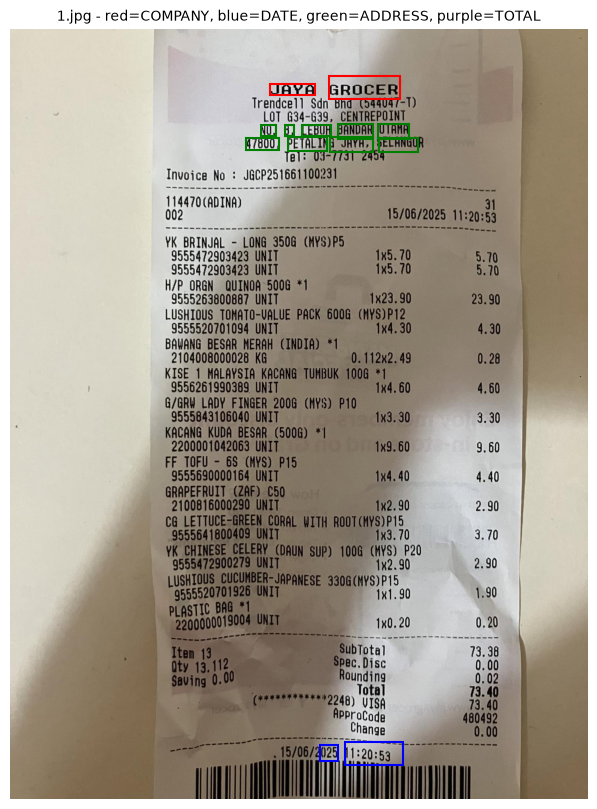

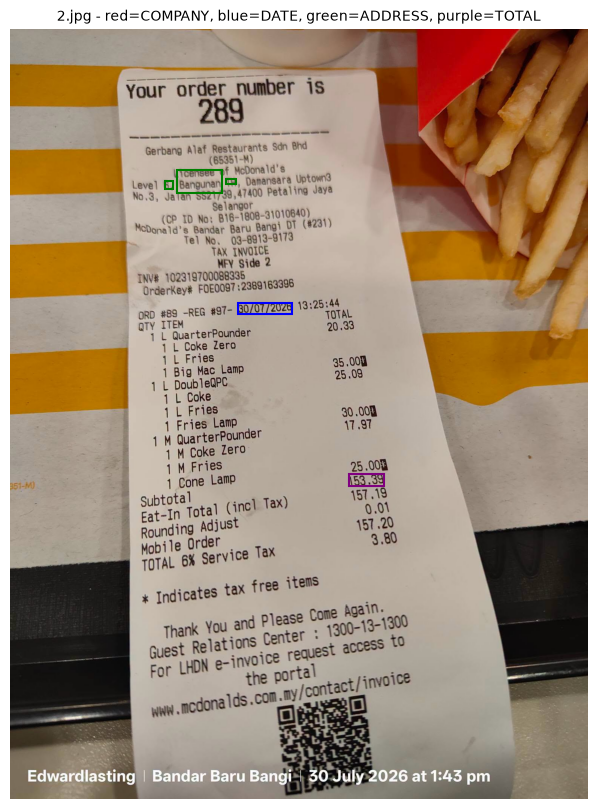

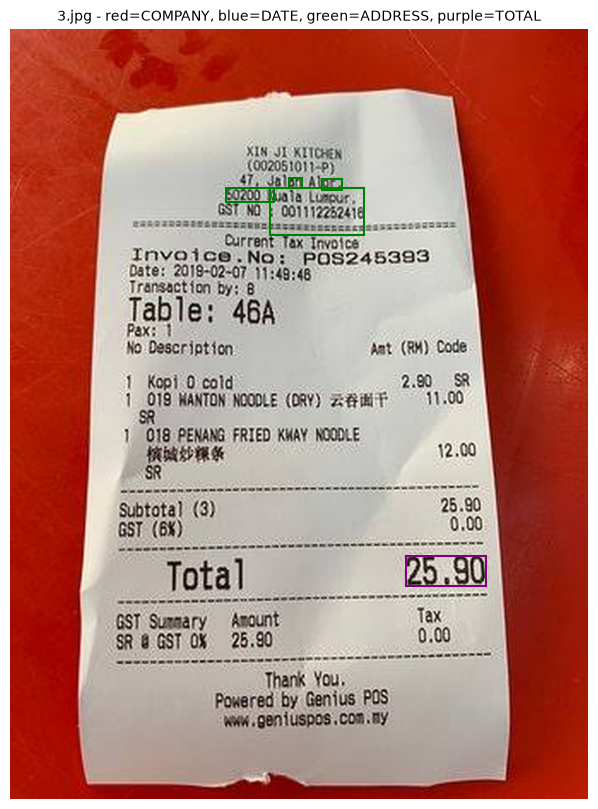

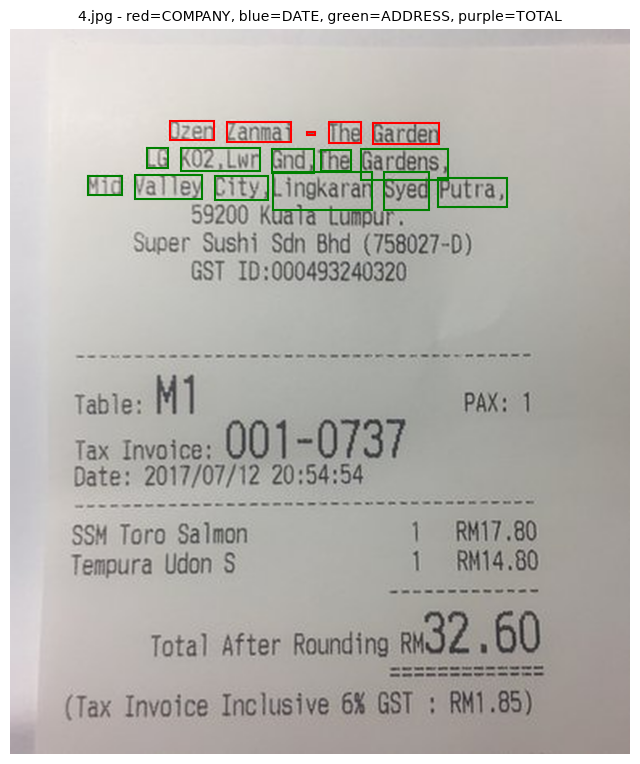

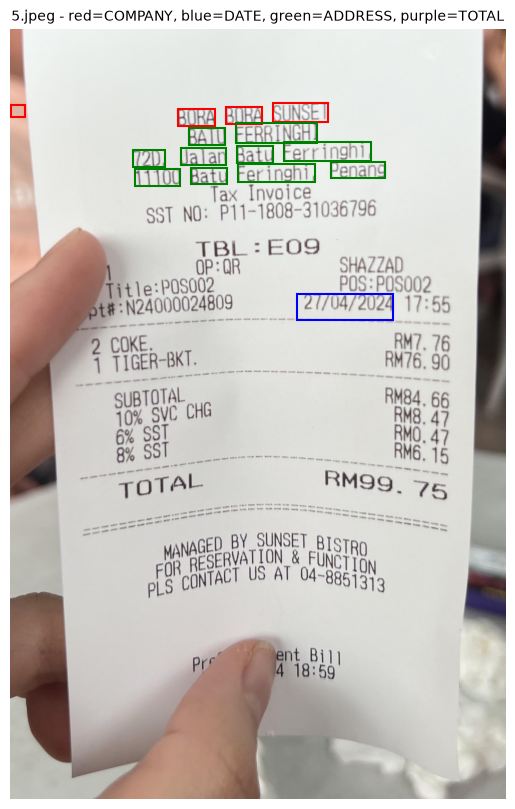

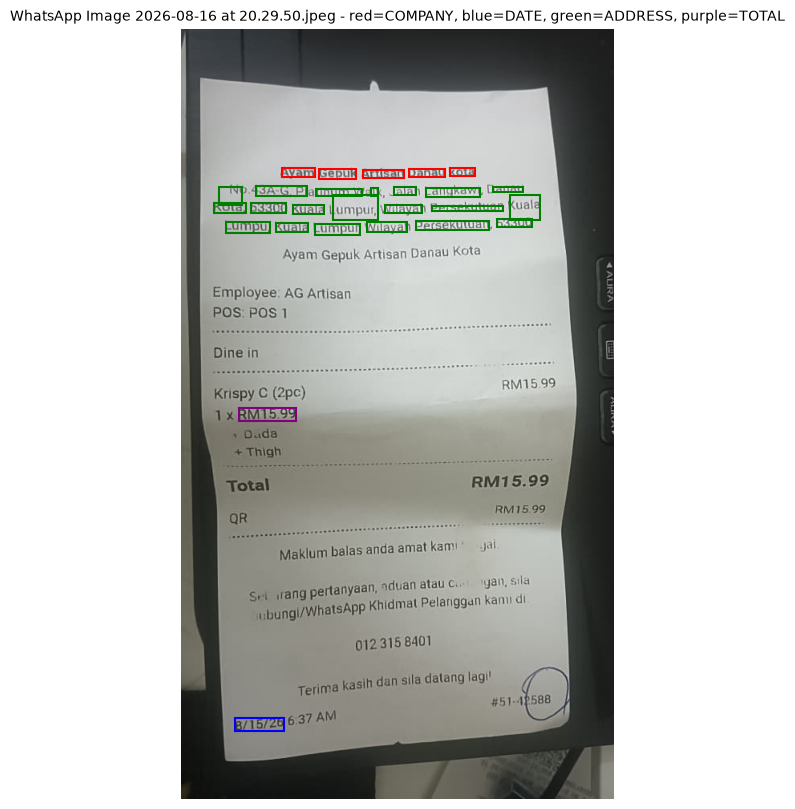

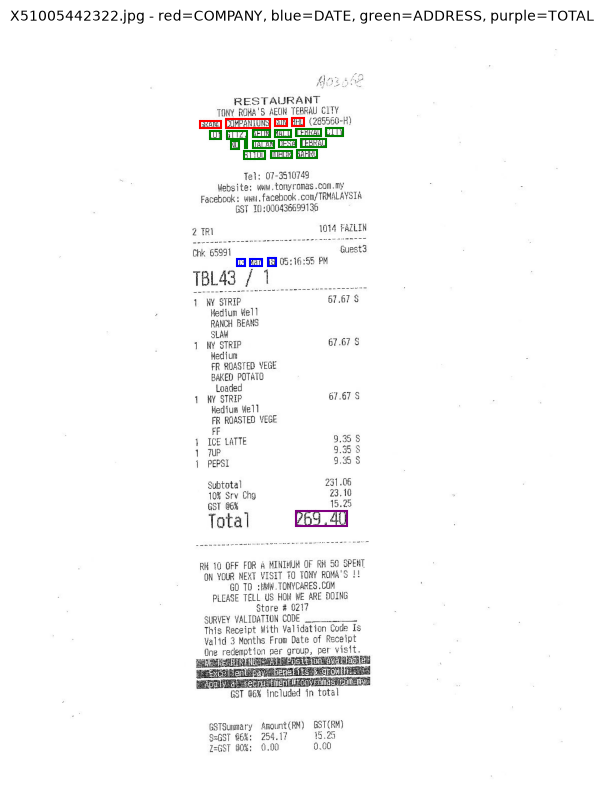

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

FIELD_COLORS = {"COMPANY": "red", "DATE": "blue", "ADDRESS": "green", "TOTAL": "purple"}

for image_path in image_paths:
    words, boxes, ocr_image = ocr_cache[image_path.name]
    if not words:
        continue
    word_tags = predict_word_tags(words, boxes, ocr_image.width, ocr_image.height, ocr_image)

    fig, ax = plt.subplots(1, figsize=(8, 10))
    ax.imshow(ocr_image)
    for box, tag in zip(boxes, word_tags):
        if tag == "O":
            continue
        field = tag.split("-", 1)[1]
        x0, y0, x2, y2 = box
        rect = patches.Rectangle(
            (x0, y0), x2 - x0, y2 - y0, linewidth=1.5,
            edgecolor=FIELD_COLORS.get(field, "black"), facecolor="none",
        )
        ax.add_patch(rect)
    ax.set_title(
        f"{image_path.name} - red=COMPANY, blue=DATE, green=ADDRESS, purple=TOTAL",
        fontsize=10,
    )
    ax.axis("off")
    plt.show()
